## Example Validation Scoring

This notebook provides an example similarity scoring assessment of a reaction dataset against OPRD-100. The dataset used in this example is the human created validation dataset used to confirm the robustness of OPRD-100 {doi}.

In [23]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
from validation import DataComparer
from plotting import Plot

# Initialise an instance of the DataComparer class with the json filepath to validation data
dc = DataComparer("../data/validation_reactions.json")

# Output filepath for plots
output_filepath = "../results/"


### Split the datasets up into groups for Scheme, Table and Experimental

In [9]:
# To achieve this, we can use the DataComparer class attributes, which have a heirarchy built in to deal with data from multiple locations

# Ground truth data from OPRD-100
oprd_data = dc.oprd_data
oprd_scheme_data = dc.oprd_scheme_data
oprd_table_data = dc.oprd_table_data
oprd_experimental_data = dc.oprd_experimental_data

print(f"Number of ground truth reactions: {len(oprd_data)}")
print(f"Number of scheme reactions: {len(oprd_scheme_data)}")
print(f"Number of table reactions: {len(oprd_table_data)}")
print(f"Number of experimental reactions: {len(oprd_experimental_data)}")
print("--------------------------------------------------")

# Validation data
val_data = dc.val_data
val_scheme_data = dc.val_scheme_data
val_table_data = dc.val_table_data
val_experimental_data = dc.val_experimental_data

print(f"Number of validation reactions: {len(val_data)}")
print(f"Number of scheme reactions: {len(val_scheme_data)}")
print(f"Number of table reactions: {len(val_table_data)}")
print(f"Number of experimental reactions: {len(val_experimental_data)}")


Number of ground truth reactions: 3878
Number of scheme reactions: 28
Number of table reactions: 158
Number of experimental reactions: 67
--------------------------------------------------
Number of validation reactions: 190
Number of scheme reactions: 26
Number of table reactions: 154
Number of experimental reactions: 10


### Metric 1: Reaction Entry Count Comparison

simple count comparison of the number of reaction entries given per doi-data location pair. Experimental data not shown here due to the constraints of the validation data used.

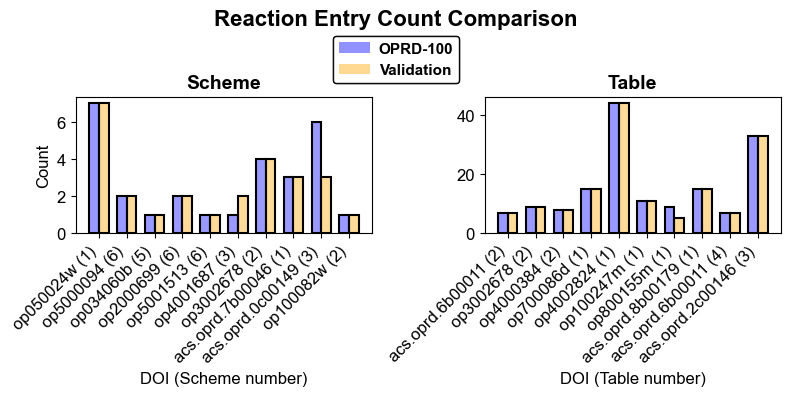

In [13]:

# Count  the number of reaction entries in each doi-data location pair
oprd_counts_table, val_counts_table = dc.get_entry_counts(
    dc.oprd_table_data,
    dc.val_table_data
)
oprd_counts_scheme, val_counts_scheme = dc.get_entry_counts(
    dc.oprd_scheme_data,
    dc.val_scheme_data
)

# Extract keys and values for plotting - remove tuple formatting for keys
oprd_counts_table_values = list(oprd_counts_table.values())
oprd_counts_table_keys = list(i[0] + f" ({i[-1]})" for i in oprd_counts_table.keys())
val_counts_table_values = list(val_counts_table.values())
val_counts_table_keys = list(i[0] + f" ({i[-1]})" for i in val_counts_table.keys())
oprd_counts_scheme_values = list(oprd_counts_scheme.values())
oprd_counts_scheme_keys = list(i[0] + f" ({i[-1]})" for i in oprd_counts_scheme.keys())
val_counts_scheme_values = list(val_counts_scheme.values())
val_counts_scheme_keys = list(i[0] + f" ({i[-1]})" for i in val_counts_scheme.keys())

# Plot the counts for schemes and tables
shared_title_fontdict = {'fontsize': 16, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 12, }
tick_fontdict = {'fontsize': 12}
legend_fontdict = {'size': 15, }
plot = Plot(n_rows=1, n_cols=2, figsize=(8, 4), shared_title="Reaction Entry Count Comparison\n", shared_title_fontdict=shared_title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict, legend_fontdict=legend_fontdict)

plot.add_bar(row=0, col=0, categories = oprd_counts_scheme_keys, values=[oprd_counts_scheme_values, val_counts_scheme_values], side_by_side=True, title="Scheme",bar_labels = ["", ""],colour = ["blue", "orange"], x_label="DOI (Scheme number)", y_label="Count", alpha=0.4, rotation=45)

plot.add_bar(row=0, col=1, categories = oprd_counts_table_keys, values=[oprd_counts_table_values, val_counts_table_values], side_by_side=True, title="Table",bar_labels = ["", ""],colour = ["blue", "orange"], x_label="DOI (Table number)", y_label="", alpha=0.4, rotation=45)


entries = [
    {'label': 'OPRD-100', 'color': 'blue', 'alpha': 0.4},
    {'label': 'Validation', 'color': 'orange', 'alpha': 0.4},
]

plot.add_figure_legend(
    entries,
    title=None,
    anchor=(0.5, 0.775),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=1,
    label_fontsize=11,
    label_fontweight='bold'
)

plot.plot(savefig=True, filepath=output_filepath + "ReactionEntryCountComparison.png")


### Metrics 2-8: Reaction Entry Similarity Scores

In [14]:
# Match reactions in each dataset based on their total scores, compute all scoring metrics based on matches
exp_results = dc.compute_comparison_scores(val_experimental_data, oprd_experimental_data)
scheme_results = dc.compute_comparison_scores(val_scheme_data, oprd_scheme_data)
table_results = dc.compute_comparison_scores(val_table_data, oprd_table_data)

# We can view the values for each reaction comparison metric as follows
table_results.head(5)

[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] Invalid InChI prefix in generating InChI Key
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] Invalid InChI prefix in generating InChI Key
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] Invalid InChI prefix in generating InChI Key
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] Invalid InChI prefix in generating InChI Key
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] Invalid InChI prefix in generating InChI Key
[15:53:18] bond type above 3 (17) is treated as unspecified!
[15:53:18] bond type above 3 (17) is treated as u

,reaction_smiles_similarity,reaction_steps_similarity,yield_similarity,reagent_similarity,reagent_name_similarity,reagent_amount_similarity,solvent_similarity,time_similarity,temperature_similarity,total_similarity,val_index,oprd_index
0,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0,0
1,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1,1
2,0.5,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.928571,2,2
3,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,3,3
4,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,4,4


### Metrics 2-8: Visualisation

#### All Reaction Location Groups Combined

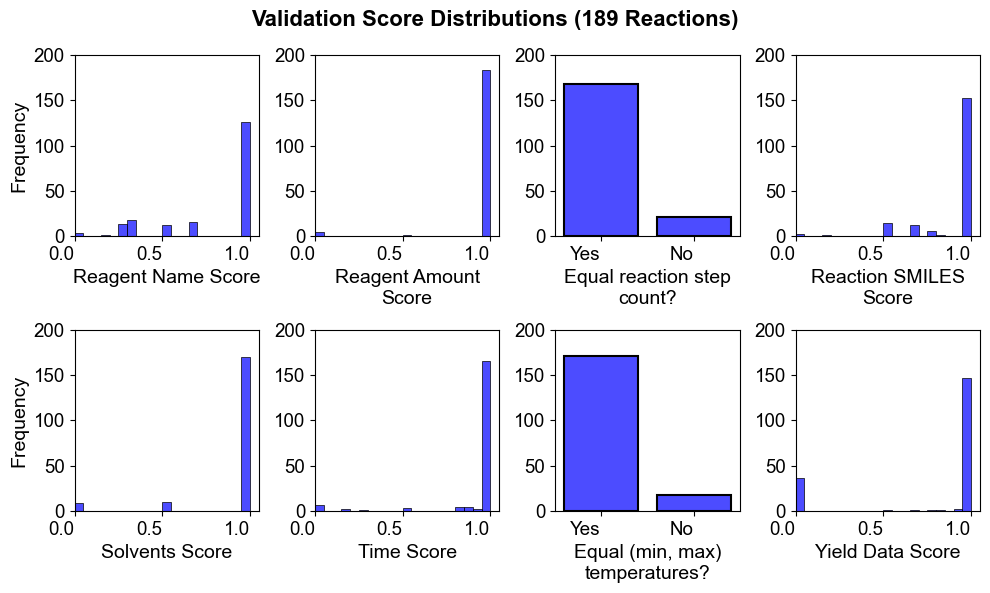

In [18]:
# PLot data for all three categories combined
combined_results = pd.concat([exp_results, scheme_results, table_results])

shared_title_fontdict = {'fontsize': 16, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 14, }
tick_fontdict = {'fontsize': 13.5}
plot = Plot(n_rows=2, n_cols=4, figsize=(10, 6), shared_title=f"Validation Score Distributions ({len(combined_results)} Reactions)", shared_title_fontdict=shared_title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict)


# count of equal reaction step counts
equal_step_counts = combined_results['reaction_steps_similarity'].value_counts().to_dict()
equal_step_count_values = [equal_step_counts.get(1.0, 0), equal_step_counts.get(0.0, 0)]
# count of equal min/max temperatures
equal_temp_counts = combined_results['temperature_similarity'].value_counts().to_dict()
equal_temp_count_values = [equal_temp_counts.get(1.0, 0), equal_temp_counts.get(0.0, 0)]


# Plotting
plot.add_hist(row=0, col=0, data=combined_results['reagent_name_similarity'], bins=20, title="", x_label="Reagent Name Score", y_label="Frequency", alpha=0.7, colour='blue',ymax=200)
plot.add_hist(row=0, col=1, data=combined_results['reagent_amount_similarity'], bins=20, title="", x_label="Reagent Amount\nScore", y_label="", alpha=0.7, colour='blue',ymax=200)
plot.add_bar(row=0, col=2, categories = ["Yes", "No"], values=equal_step_count_values, title="", x_label="Equal reaction step\ncount?", y_label="", alpha=0.7, colour='blue',ymax=200)
plot.add_hist(row=0, col=3, data=combined_results['reaction_smiles_similarity'], bins=20, title="", x_label="Reaction SMILES\nScore", y_label="", alpha=0.7, colour='blue',ymax=200)
plot.add_hist(row=1, col=0, data=combined_results['solvent_similarity'], bins=20, title="", x_label="Solvents Score", y_label="Frequency", alpha=0.7, colour='blue',ymax=200)
plot.add_hist(row=1, col=1, data=combined_results['time_similarity'], bins=20, title="", x_label="Time Score", y_label="", alpha=0.7, colour='blue',ymax=200)
plot.add_bar(row=1, col=2, categories=["Yes", "No"], values=equal_temp_count_values, title="", x_label="Equal (min, max)\ntemperatures?", y_label="", alpha=0.7, colour='blue', ymax=200)
plot.add_hist(row=1, col=3, data=combined_results['yield_similarity'], bins=20, title="", x_label="Yield Data Score", y_label="", alpha=0.7, colour='blue', ymax=200)


plot.plot(savefig=True, filepath=output_filepath + "CombinedValidationSimilarityScoreDistributions.png")

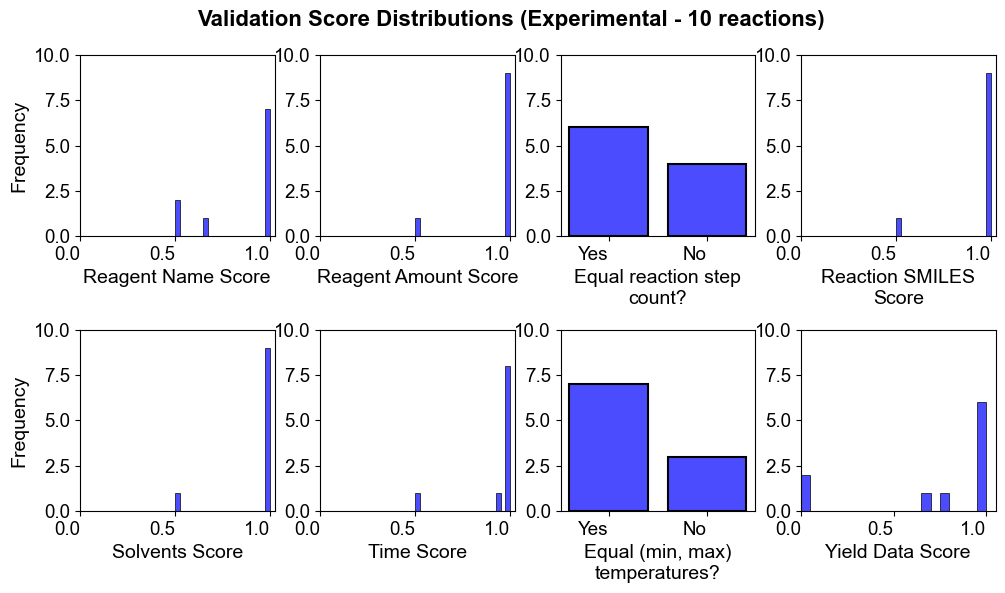

In [19]:
# Plot data for experimental category only
shared_title_fontdict = {'fontsize': 16, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 14, }
tick_fontdict = {'fontsize': 13.5}
plot = Plot(n_rows=2, n_cols=4, figsize=(10, 6), shared_title="Validation Score Distributions (Experimental - 10 reactions)", shared_title_fontdict=shared_title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict)

# count of equal reaction step counts
equal_step_counts = exp_results['reaction_steps_similarity'].value_counts().to_dict()
equal_step_count_values = [equal_step_counts.get(1.0, 0), equal_step_counts.get(0.0, 0)]
# count of equal min/max temperatures
equal_temp_counts = exp_results['temperature_similarity'].value_counts().to_dict()
equal_temp_count_values = [equal_temp_counts.get(1.0, 0), equal_temp_counts.get(0.0, 0)]

# Plotting
plot.add_hist(row=0, col=0, data=exp_results['reagent_name_similarity'], bins=20, title="", x_label="Reagent Name Score", y_label="Frequency", alpha=0.7, colour='blue',ymax=10)
plot.add_hist(row=0, col=1, data=exp_results['reagent_amount_similarity'], bins=20, title="", x_label="Reagent Amount Score", y_label="", alpha=0.7, colour='blue',ymax=10)
plot.add_bar(row=0, col=2, categories = ["Yes", "No"], values=equal_step_count_values, title="", x_label="Equal reaction step\ncount?", y_label="", alpha=0.7, colour='blue',ymax=10)
plot.add_hist(row=0, col=3, data=exp_results['reaction_smiles_similarity'], bins=20, title="", x_label="Reaction SMILES\nScore", y_label="", alpha=0.7, colour='blue',ymax=10)
plot.add_hist(row=1, col=0, data=exp_results['solvent_similarity'], bins=20, title="", x_label="Solvents Score", y_label="Frequency", alpha=0.7, colour='blue',ymax=10)
plot.add_hist(row=1, col=1, data=exp_results['time_similarity'], bins=20, title="", x_label="Time Score", y_label="", alpha=0.7, colour='blue',ymax=10)
plot.add_bar(row=1, col=2, categories=["Yes", "No"], values=equal_temp_count_values, title="", x_label="Equal (min, max)\ntemperatures?", y_label="", alpha=0.7, colour='blue', ymax=10)
plot.add_hist(row=1, col=3, data=exp_results['yield_similarity'], bins=20, title="", x_label="Yield Data Score", y_label="", alpha=0.7, colour='blue', ymax=10)
plot.plot(savefig=True, filepath=output_filepath + "ExperimentalValidationSimilarityScoreDistributions.png")

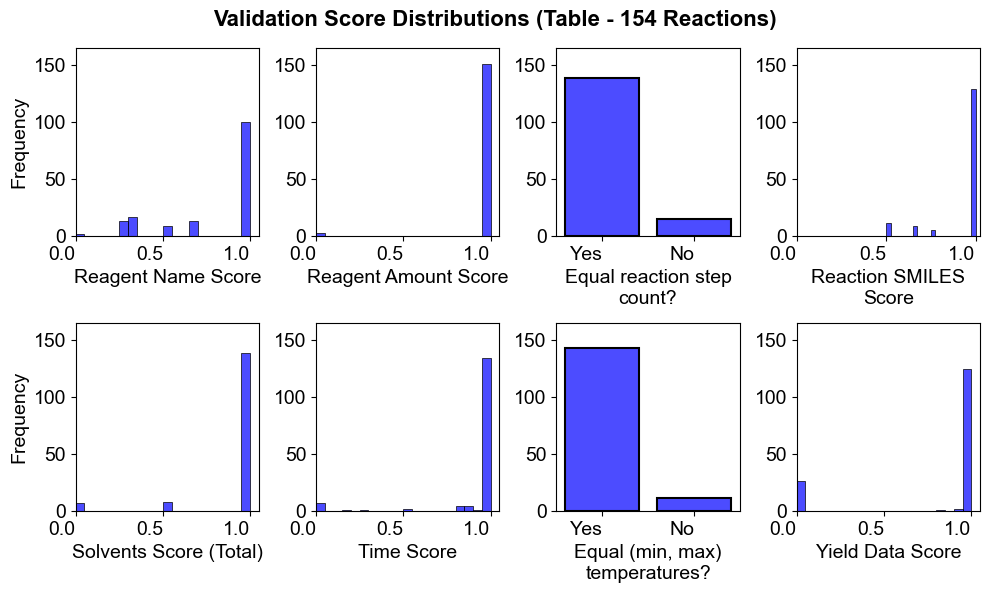

In [20]:
shared_title_fontdict = {'fontsize': 16, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 14, }
tick_fontdict = {'fontsize': 14}
plot = Plot(n_rows=2, n_cols=4, figsize=(10, 6), shared_title=f"Validation Score Distributions (Table - {len(table_results)} Reactions)", shared_title_fontdict=shared_title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict)


# count of equal reaction step counts
equal_step_counts = table_results['reaction_steps_similarity'].value_counts().to_dict()
equal_step_count_values = [equal_step_counts.get(1.0, 0), equal_step_counts.get(0.0, 0)]
# count of equal min/max temperatures
equal_temp_counts = table_results['temperature_similarity'].value_counts().to_dict()
equal_temp_count_values = [equal_temp_counts.get(1.0, 0), equal_temp_counts.get(0.0, 0)]

plot.add_hist(row=0, col=0, data=table_results['reagent_name_similarity'], bins=20, title="", x_label="Reagent Name Score", y_label="Frequency", alpha=0.7, colour='blue',ymax=165)
plot.add_hist(row=0, col=1, data=table_results['reagent_amount_similarity'], bins=20, title="", x_label="Reagent Amount Score", y_label="", alpha=0.7, colour='blue',ymax=165)
plot.add_bar(row=0, col=2, categories = ["Yes", "No"], values=equal_step_count_values, title="", x_label="Equal reaction step\ncount?", y_label="", alpha=0.7, colour='blue',ymax=165)
plot.add_hist(row=0, col=3, data=table_results['reaction_smiles_similarity'], bins=20, title="", x_label="Reaction SMILES\nScore", y_label="", alpha=0.7, colour='blue',ymax=165)
plot.add_hist(row=1, col=0, data=table_results['solvent_similarity'], bins=20, title="", x_label="Solvents Score (Total)", y_label="Frequency", alpha=0.7, colour='blue',ymax=165)
plot.add_hist(row=1, col=1, data=table_results['time_similarity'], bins=20, title="", x_label="Time Score", y_label="", alpha=0.7, colour='blue',ymax=165)
plot.add_bar(row=1, col=2, categories=["Yes", "No"], values=equal_temp_count_values, title="", x_label="Equal (min, max)\ntemperatures?", y_label="", alpha=0.7, colour='blue', ymax=165)
plot.add_hist(row=1, col=3, data=table_results['yield_similarity'], bins=20, title="", x_label="Yield Data Score", y_label="", alpha=0.7, colour='blue', ymax=165)
plot.plot(savefig=True, filepath=output_filepath + "TableValidationSimilarityScoreDistributions.png")

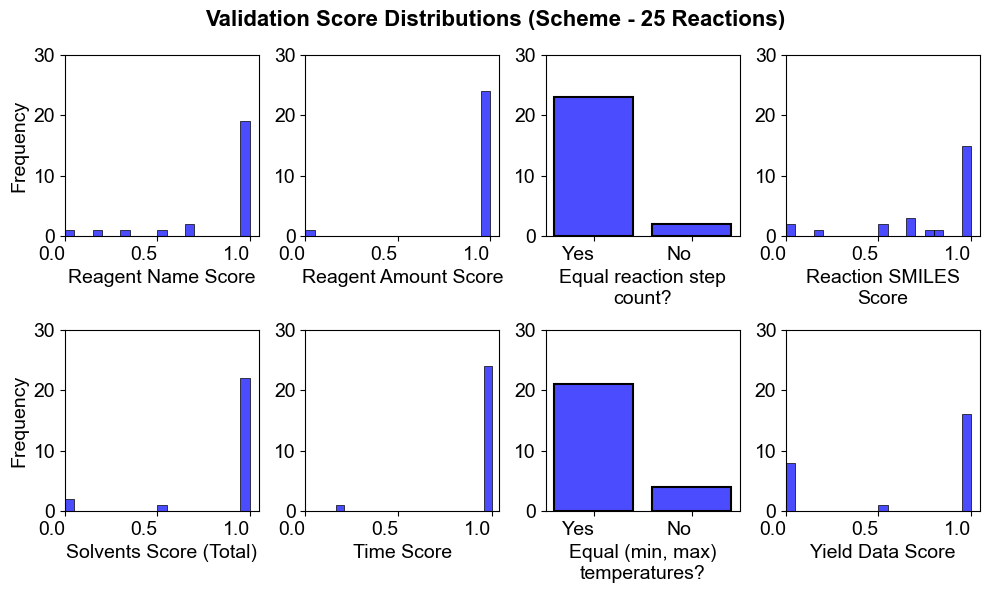

In [21]:
shared_title_fontdict = {'fontsize': 16, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 14, }
tick_fontdict = {'fontsize': 14}
plot = Plot(n_rows=2, n_cols=4, figsize=(10, 6), shared_title=f"Validation Score Distributions (Scheme - {len(scheme_results)} Reactions)", shared_title_fontdict=shared_title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict)


# count of equal reaction step counts
equal_step_counts = scheme_results['reaction_steps_similarity'].value_counts().to_dict()
equal_step_count_values = [equal_step_counts.get(1.0, 0), equal_step_counts.get(0.0, 0)]
# count of equal min/max temperatures
equal_temp_counts = scheme_results['temperature_similarity'].value_counts().to_dict()
equal_temp_count_values = [equal_temp_counts.get(1.0, 0), equal_temp_counts.get(0.0, 0)]

plot.add_hist(row=0, col=0, data=scheme_results['reagent_name_similarity'], bins=20, title="", x_label="Reagent Name Score", y_label="Frequency", alpha=0.7, colour='blue', ymax=30)
plot.add_hist(row=0, col=1, data=scheme_results['reagent_amount_similarity'], bins=20, title="", x_label="Reagent Amount Score", y_label="", alpha=0.7, colour='blue',ymax=30)
plot.add_bar(row=0, col=2, categories = ["Yes", "No"], values=equal_step_count_values, title="", x_label="Equal reaction step\ncount?", y_label="", alpha=0.7, colour='blue',ymax=30)
plot.add_hist(row=0, col=3, data=scheme_results['reaction_smiles_similarity'], bins=20, title="", x_label="Reaction SMILES\nScore", y_label="", alpha=0.7, colour='blue',ymax=30)
plot.add_hist(row=1, col=0, data=scheme_results['solvent_similarity'], bins=20, title="", x_label="Solvents Score (Total)", y_label="Frequency", alpha=0.7, colour='blue',ymax=30)
plot.add_hist(row=1, col=1, data=scheme_results['time_similarity'], bins=20, title="", x_label="Time Score", y_label="", alpha=0.7, colour='blue',ymax=30)
plot.add_bar(row=1, col=2, categories=["Yes", "No"], values=equal_temp_count_values, title="", x_label="Equal (min, max)\ntemperatures?", y_label="", alpha=0.7, colour='blue', ymax=30)
plot.add_hist(row=1, col=3, data=scheme_results['yield_similarity'], bins=20, title="", x_label="Yield Data Score", y_label="", alpha=0.7, colour='blue', ymax=30)
plot.plot(savefig=True, filepath=output_filepath + "SchemeValidationSimilarityScoreDistributions.png")

### HEATMAPS FOR TOTAL SIMILARITY SCORES

These plots show the maximum score achieved for each OPRD-100 reaction, multiple maxima indicates that there may be issues with reaction pairing by linear_sum_assignment.

Number of OPRD-100 experimental entries with multiple maximum similarity matches in validation set: 0


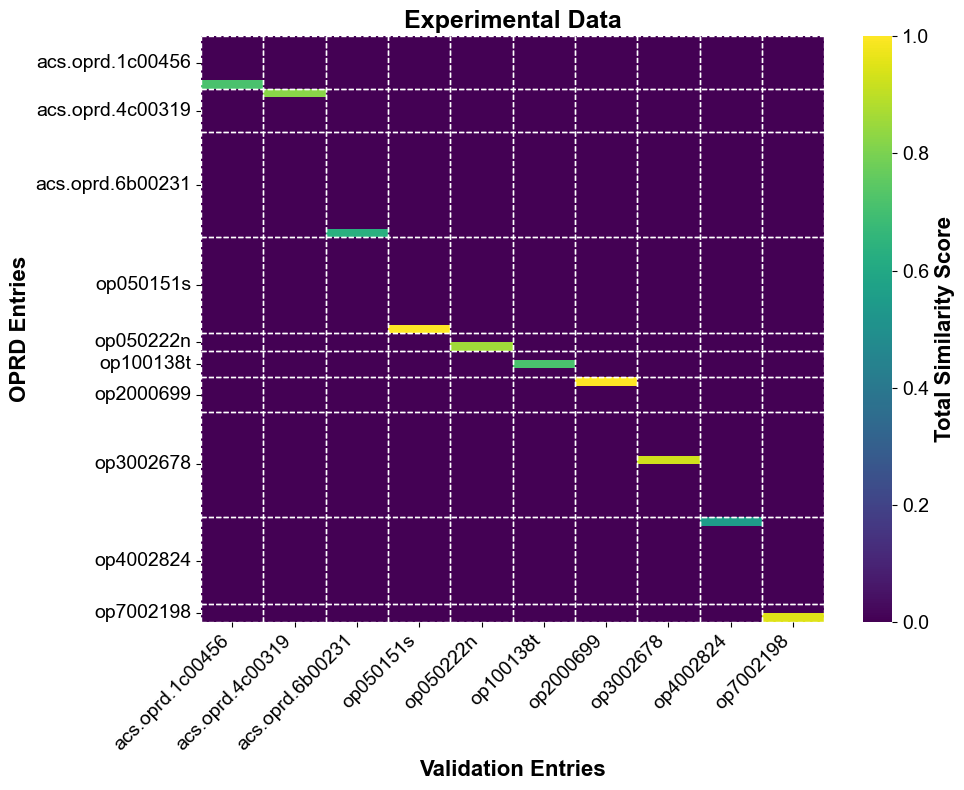

In [25]:
comparison_array = dc.compare_data(dc.oprd_experimental_data, dc.val_experimental_data, metric='total_similarity',return_array=True)
row_max = comparison_array.max(axis=0, keepdims=True)
mask = comparison_array == row_max
out = np.where(mask, comparison_array, np.zeros_like(comparison_array))
nonzero_counts = (out != 0).sum(axis=1)
rows_with_multiple = np.where(nonzero_counts > 1)[0]
num_rows_with_multiple = rows_with_multiple.size
print(f"Number of OPRD-100 experimental entries with multiple maximum similarity matches in validation set: {num_rows_with_multiple}")
dc.generate_heatmap(
    out, 
    val_subset=dc.val_experimental_data, 
    oprd_subset=dc.oprd_experimental_data, 
    title = "Experimental Data", 
    xlabel = "Validation Entries", 
    ylabel = "OPRD Entries", 
    line_col="white",
    figsize=(10, 8),
    title_fontdict={'fontsize': 18, 'fontweight': 'bold'},
    label_fontdict={'fontsize': 16, 'fontweight': 'bold'},
    tick_fontdict={'fontsize': 14},
    show_plot=True,
    save_path=output_filepath + "experimental_data_validation_heatmap_max_only.png"
)

Number of OPRD-100 table entries with multiple maximum similarity matches in validation set: 22


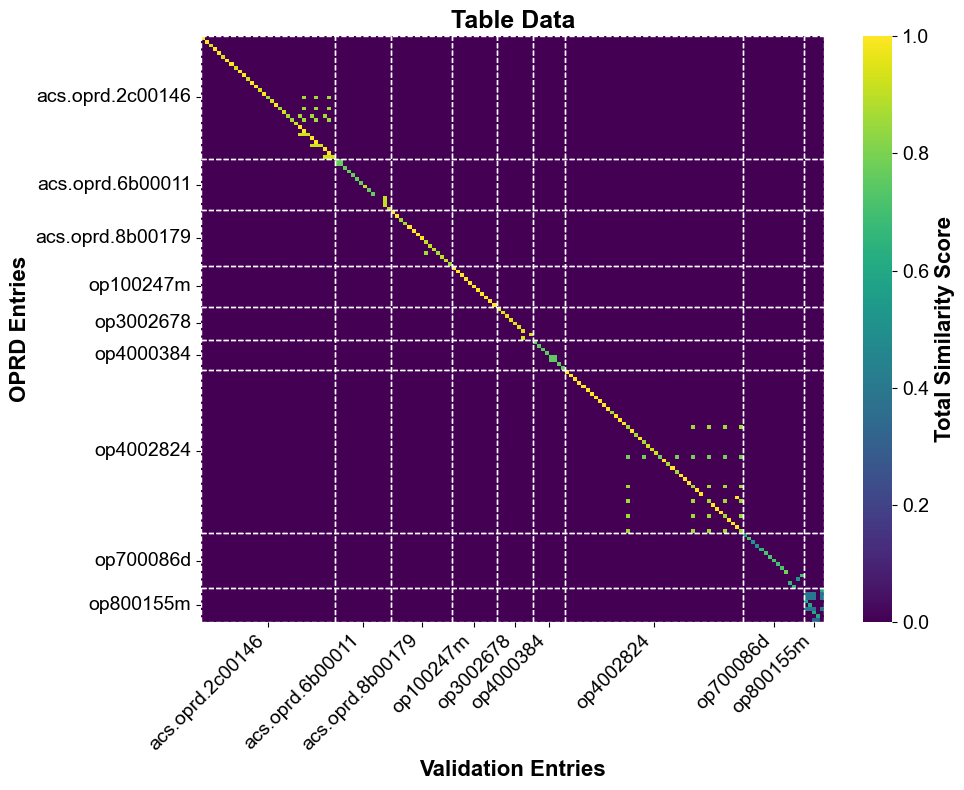

In [26]:
comparison_array = dc.compare_data(dc.oprd_table_data, dc.val_table_data, metric='total_similarity', return_array=True)
row_max = comparison_array.max(axis=1, keepdims=True)
mask = comparison_array == row_max
out = np.where(mask, comparison_array, np.zeros_like(comparison_array))
nonzero_counts = (out != 0).sum(axis=1)
rows_with_multiple = np.where(nonzero_counts > 1)[0]
num_rows_with_multiple = rows_with_multiple.size
print(f"Number of OPRD-100 table entries with multiple maximum similarity matches in validation set: {num_rows_with_multiple}")
dc.generate_heatmap(out, val_subset=dc.val_table_data, oprd_subset=dc.oprd_table_data, title = "Table Data", xlabel = "Validation Entries", ylabel = "OPRD Entries", line_col="white",
    figsize=(10, 8),
    title_fontdict={'fontsize': 18, 'fontweight': 'bold'},
    label_fontdict={'fontsize': 16, 'fontweight': 'bold'},
    tick_fontdict={'fontsize': 14},
    save_path=output_filepath + "table_data_validation_heatmap_max_only.png",
    show_plot=True)

[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] Invalid InChI prefix in generating InChI Key
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] Invalid InChI prefix in generating InChI Key
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] Invalid InChI prefix in generating InChI Key
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] Invalid InChI prefix in generating InChI Key
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] Invalid InChI prefix in generating InChI Key
[16:07:37] bond type above 3 (17) is treated as unspecified!
[16:07:37] bond type above 3 (17) is treated as u

Number of OPRD-100 scheme entries with multiple maximum similarity matches in validation set: 0


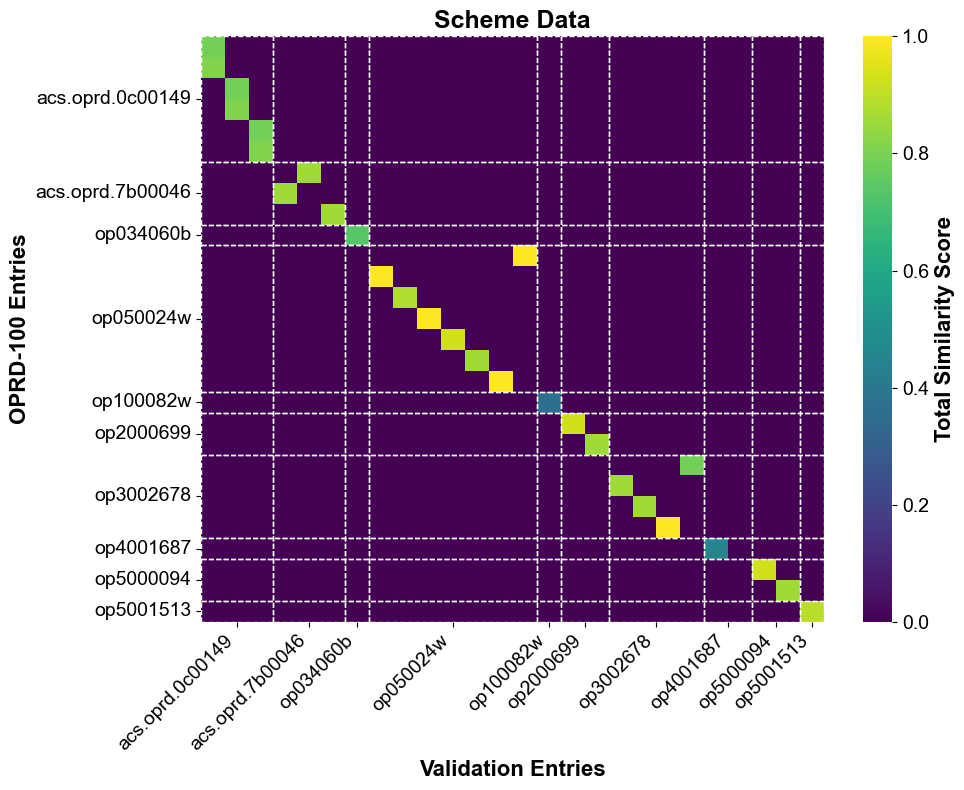

In [27]:
comparison_array = dc.compare_data(dc.oprd_scheme_data, dc.val_scheme_data, metric='total_similarity', return_array=True)
row_max = comparison_array.max(axis=1, keepdims=True)
mask = comparison_array == row_max
out = np.where(mask, comparison_array, np.zeros_like(comparison_array))
nonzero_counts = (out != 0).sum(axis=1)
rows_with_multiple = np.where(nonzero_counts > 1)[0]
num_rows_with_multiple = rows_with_multiple.size
print(f"Number of OPRD-100 scheme entries with multiple maximum similarity matches in validation set: {num_rows_with_multiple}")
dc.generate_heatmap(out, val_subset=dc.val_scheme_data, oprd_subset=dc.oprd_scheme_data, title = "Scheme Data", xlabel = "Validation Entries", ylabel = "OPRD-100 Entries", line_col="white",
    figsize=(10, 8),
    title_fontdict={'fontsize': 18, 'fontweight': 'bold'},
    label_fontdict={'fontsize': 16, 'fontweight': 'bold'},
    tick_fontdict={'fontsize': 14}, show_plot=True,
    save_path=output_filepath + "scheme_data_validation_heatmap_max_only.png")

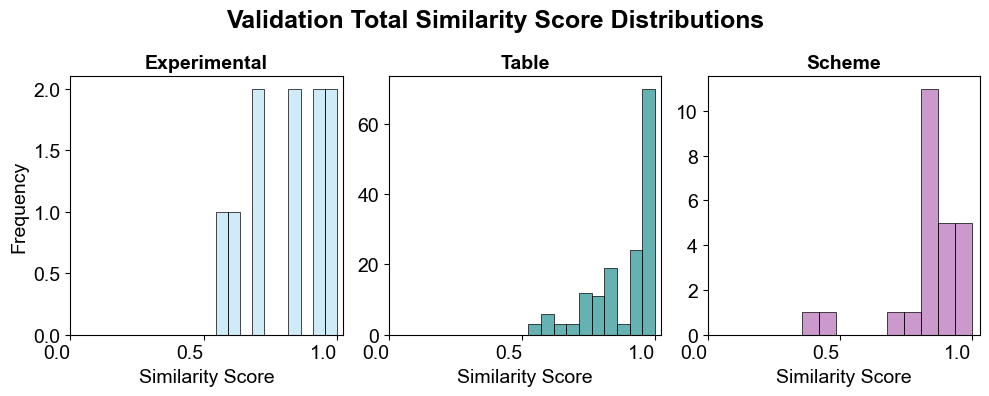

In [29]:
shared_title_fontdict = {'fontsize': 18, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 14, }
tick_fontdict = {'fontsize': 14}
plot = Plot(n_rows=1, n_cols=3, figsize=(10, 4), shared_title="Validation Total Similarity Score Distributions", shared_title_fontdict=shared_title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict)

plot.add_hist(row=0, col=0, data=exp_results['total_similarity'], title="Experimental", x_label="Similarity Score", y_label="Frequency", colour='skyblue', alpha=0.4)
plot.add_hist(row=0, col=1, data=table_results['total_similarity'], title="Table", x_label="Similarity Score", y_label="", colour='teal', alpha=0.6, )
plot.add_hist(row=0, col=2, data=scheme_results['total_similarity'], title="Scheme", x_label="Similarity Score", y_label="", colour='purple', alpha=0.4)

plot.plot(savefig=True, filepath=output_filepath + "validation_total_similarity_histograms.png")